# Task 1: Load and Explore a Dataset

**Dataset chosen:** Iris flowers dataset (classic ML benchmark)  
**Goal:** Get comfortable loading data, looking at basic stats, and doing some simple visualizations.

The iris dataset has 150 samples across 3 species of flowers: *Setosa*, *Versicolor*, and *Virginica*. Each sample has 4 measurements — sepal length, sepal width, petal length, petal width.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# load the iris dataset from sklearn and convert to a DataFrame
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (150, 5)


## First look at the data

In [2]:
# first 5 rows to get a feel for the structure
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# check how many samples per class — balanced dataset
print(df['species'].value_counts())
print()
# check for missing values
print("Missing values:")
print(df.isnull().sum())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


## Summary Statistics

In [4]:
# describe gives count, mean, std, min, quartiles, max
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
# groupby species to see how the means differ across classes
df.groupby('species').mean().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


## Data Visualization

A few plots to understand the distributions and relationships.

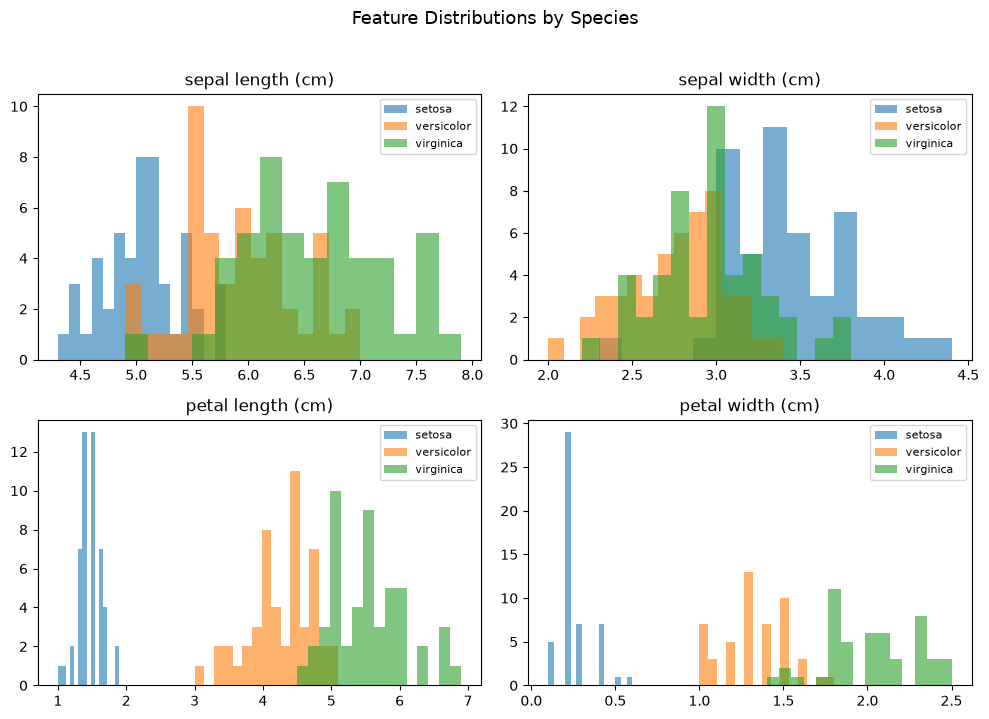

In [6]:
# histograms for each feature
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
features = iris.feature_names

for ax, feat in zip(axes.flatten(), features):
    for species in iris.target_names:
        ax.hist(df[df['species'] == species][feat], bins=15, alpha=0.6, label=species)
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Species', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('task1_histograms.png', dpi=100, bbox_inches='tight')
plt.show()

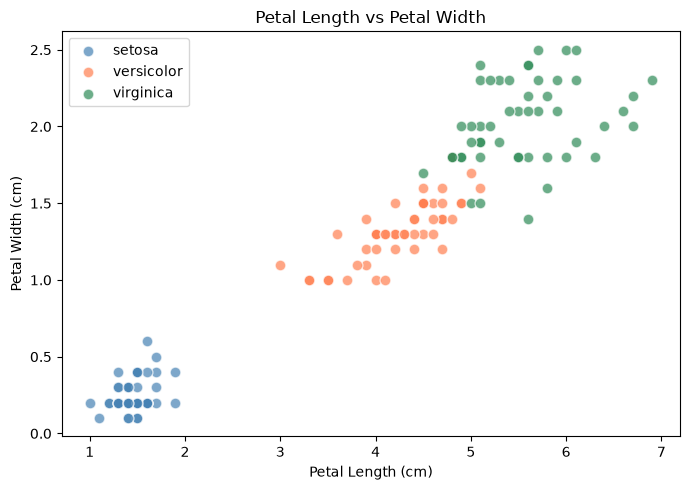

In [7]:
# scatter plot: petal length vs petal width — these two features separate species nicely
plt.figure(figsize=(7, 5))
colors = {'setosa': 'steelblue', 'versicolor': 'coral', 'virginica': 'seagreen'}

for species, grp in df.groupby('species'):
    plt.scatter(grp['petal length (cm)'], grp['petal width (cm)'],
                label=species, color=colors[species], alpha=0.7, edgecolors='white', s=60)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Petal Length vs Petal Width')
plt.legend()
plt.tight_layout()
plt.savefig('task1_scatter.png', dpi=100)
plt.show()

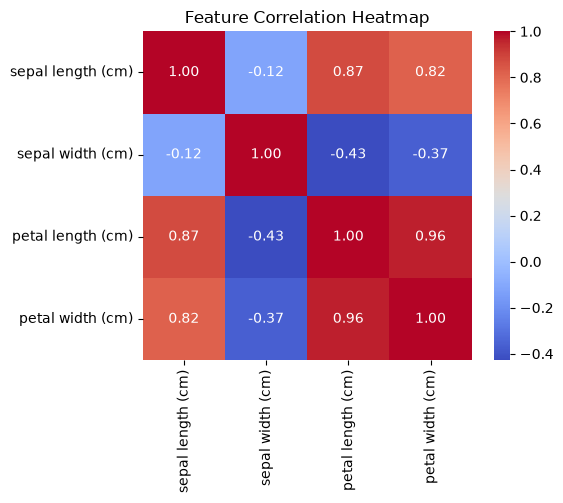

In [8]:
# correlation heatmap (numeric columns only)
plt.figure(figsize=(6, 5))
corr = df.drop('species', axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('task1_correlation.png', dpi=100)
plt.show()

## Observations

- The dataset is perfectly balanced (50 samples per class) with no missing values.
- **Petal length** and **petal width** are highly correlated (r ≈ 0.96) and are the most useful features for separating species.
- Setosa is clearly separable from the other two species using petal measurements alone.
- Versicolor and Virginica overlap somewhat, so a classifier will need more than one feature to distinguish them reliably.
- Sepal width has the weakest correlation with the other features.